### Libraries and Imports

In [64]:
import sys
sys.path.append("../src")
print(sys.path)

from system import System
from dynamics import streaming, collision, distributeToCells
from observables import system_momentum, system_kinetic

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import poisson

['/usr/lib64/python314.zip', '/usr/lib64/python3.14', '/usr/lib64/python3.14/lib-dynload', '', '/home/olegoniy/Desktop/MPC_Project/lib64/python3.14/site-packages', '/home/olegoniy/Desktop/MPC_Project/lib/python3.14/site-packages', '../src', '../src', '../src', '../src', '../src', '../src']


### System Settings 
#### Solvent

In [65]:
system = System(
    N = 83324, 
    box = [10, 10, 10], 
    a = 1.0, 
    h = 0.1, 
    m = 1.0, 
    kBT = 1.0, 
    alpha_deg=30, 
    seed=1      
    )

### Velocity distribution of solvent particles 
___IMPORTANT!___(I think): Here we observe only 1st component (i.e. x-Direction), not the absolute value of velosities

In [66]:
def velocityDistr(system):

    for i in range(1000):
        streaming(system)
        collision(system)

    vx = system.v[:, 0]

    sigma = np.sqrt(system.kBT / system.m)

    x = np.linspace(vx.min(), vx.max(), 300)

    pdf = (
        1 / (np.sqrt(2 * np.pi) * sigma)
        * np.exp(-x**2 / (2 * sigma**2))
    )

    plt.hist(vx, bins=200, density=True, alpha=0.6, label="Simulation")
    plt.plot(x, pdf, label="Maxwell-Boltzmann")

    plt.xlabel(r"$v_x$")
    plt.ylabel(r"$P(v_x)$")
    plt.legend()
    plt.tight_layout()
    plt.show()


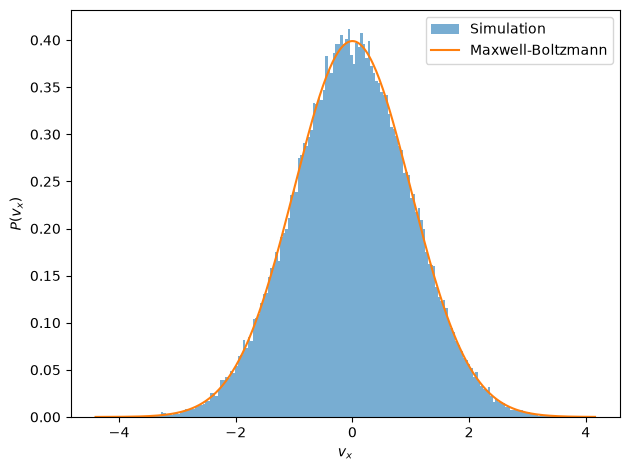

In [67]:
velocityDistr(system)

Here also Gaussian, cause there's no multiplication factor of $v^2$, so probably what was meant in the book

### Velocity Magnitude Distribution

In [68]:
def velocityMagnitudeDistr(system):
    for i in range(1000):
        streaming(system)
        collision(system)

    v_abs = np.sqrt(np.sum(system.v**2, axis=1))

    sigma = np.sqrt(system.kBT / system.m)

    x = np.linspace(v_abs.min(), v_abs.max(), 300)

    pdf = (
        4*np.pi*(1/(2*np.pi*sigma)**(3.0/2))*x**2*np.exp(-x**2/(2*sigma))
    )
    # Since v_abs is a square, the actual values are roots
    plt.hist(v_abs, bins=200, density=True, alpha=0.6, label="Simulation")
    plt.plot(x, pdf, label="Maxwell-Boltzmann")

    plt.xlabel(r"$v_x$")
    plt.ylabel(r"$P(v_x)$")
    plt.legend()
    plt.tight_layout()
    plt.show()

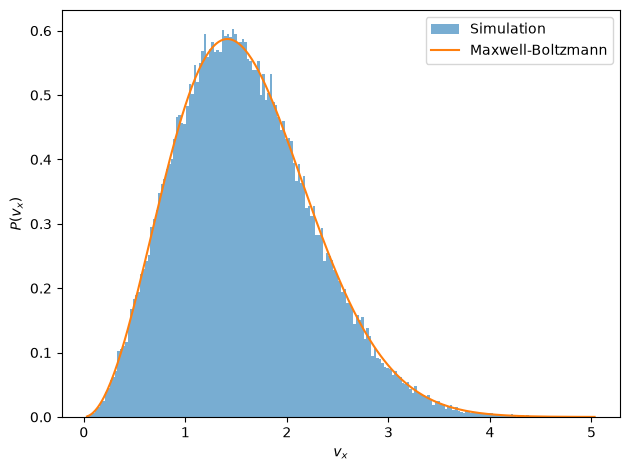

In [69]:
velocityMagnitudeDistr(system)

### Number of Particles in a Cell Distribution

In [70]:
def particlesInCellDistr(system):
    for i in range(10):
        streaming(system)
        collision(system)

    cells = distributeToCells(system)

    nInCell = np.array([len(cell) for cell in cells.flat])

    nMean = nInCell.mean()

    n_values = np.arange(0, nInCell.max() + 1)

    bin_edges = np.arange(
        nInCell.max() + 2
    ) - 0.5    

    plt.figure(figsize=(7, 4))

    plt.hist(
        nInCell,
        bins=bin_edges,
        density=True,
        alpha=0.6,
        label="Simulation"
    )


    plt.plot(
        n_values,
        poisson.pmf(n_values, nMean),
        "-",
        label=fr"Poisson, $\lambda={nMean:.2f}$"
    )

    plt.xlabel(r"Number of particles in a cell $N_c$")
    plt.ylabel(r"Probability $P(N_c)$")
    plt.title("Cell occupancy distribution")
    plt.legend()
    plt.tight_layout()

    plt.show()
    

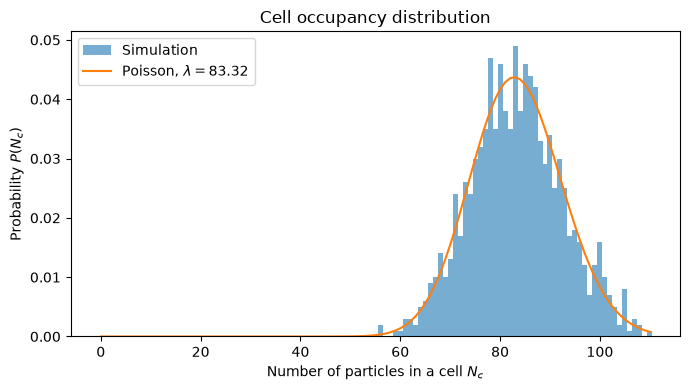

In [71]:
particlesInCellDistr(system)

#### Polymer

In [40]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../src")

from polymer import Polymer
polymer = Polymer(
    nMonomers=10,
    bondLength=0.5,
    m=4,
    box=[5,5,5],
    kBT=1,
    seed=1337
)


### Genaration of a Polymer (__Linear__)

Rel. distnces between monomers:[np.float64(1.0405869469440339), np.float64(1.0042928989858253), np.float64(0.9798967699120628), np.float64(1.0144829053312647), np.float64(0.9521866260624415), np.float64(0.9673700001707615), np.float64(1.0102194158753066), np.float64(0.9632056188267587), np.float64(1.0470146245379965)]


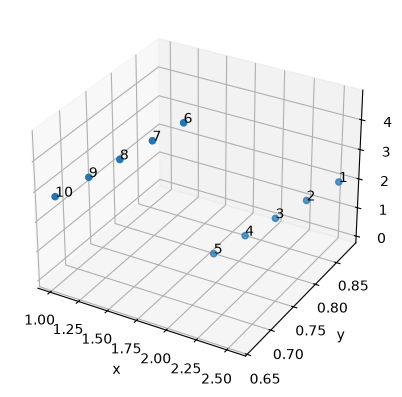

In [46]:
polymer.generateLinearPositions()

#print(f"Positions of monomers:{polymer.r}\n")
print(f"Rel. distnces between monomers:{[polymer.distInBC(i, i+1)/polymer.bondLength for i in range(0, polymer.nMonomers-1)]}") 

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    polymer.r[:, 0],
    polymer.r[:, 1],
    polymer.r[:, 2]
)
for i in range(len(polymer.r)):
    ax.text(polymer.r[i, 0], polymer.r[i, 1], polymer.r[i, 2], str(i+1))

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()